# 02 · Experten + Gating — SQI-gated Mixture of Experts (aufgeräumt)

**Bachelorarbeit: AF-Detektion in kontaktlosen Signalen · Nik Büttner · RWTH Aachen**

Aufgeräumte Neufassung von `02_experts_gating.ipynb`. Gleiche Architektur, klare
Reihenfolge, keine Duplikate. Roter Faden = **erst die Experten verstehen und
verbessern, dann das Gating prüfen**:

| Abschnitt | Inhalt | Ziel-Item |
|---|---|---|
| 1 | Setup, Feature-Tabelle, Reliability-Ziel | — |
| 2 | Experten solo: OOF-AUC + PPG-Ablation (die zu schlagende Decke) | 8 |
| 3 | **Fehleranalyse: was macht ein Fenster für cECG/BCG schwer?** | 2 |
| 4 | **Detektions-Check (RR-Treue vs. GT, GT-Güte je Fenster)** | 5 |
| 5 | **SQI-Check: sagt der SQI die Zuverlässigkeit überhaupt vorher?** | 6 |
| 6 | Fusion & Gate-Vergleich (equal/ridge/gb) + Konfidenzintervalle | 8 |
| 7 | **Gewichts-Inspektion: ein gutes vs. ein schlechtes Fenster** | 7 |
| 8 | Adaptivität: bringt die fensterweise SQI-Steuerung etwas? | 7/8 |
| 9 | **Experten verbessern: neue Features (v2), stärkere Klassifikatoren, 10-s-Fenster** | 1/3 |
| 10 | Optionaler Anhang: torch-MLP-Gate (Optuna), GT-Güte-Detail | — |

> **Voraussetzung:** `01_features_sqi.ipynb` wurde mit dem aktuellen `src/` gelaufen
> (Feature-Version `v2_acf_xmodal` — enthält die ACF-Regularitäts- und robusten
> RR-Features sowie die `sqi_xmodal_*`-Gate-Eingänge). `neurokit2` wird für die
> GT-R-Zacken empfohlen.

## 1 · Setup, Feature-Tabelle, Reliability-Ziel

In [48]:
import sys, os

# Set working directory to your project root
os.chdir('/home/nik/projects/BA')

# Add both root and src to path
sys.path.insert(0, '/home/nik/projects/BA')
sys.path.insert(0, '/home/nik/projects/BA/src')

In [88]:
import os, sys, glob
import numpy as np, pandas as pd

NB_DIR  = os.path.abspath('')
SRC_DIR = os.path.abspath(os.path.join(NB_DIR, '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import extract as E
import experts as X
import reliability as R
import gating as G
import fusion_cv as CV
import models as M

DATA_ROOT = 'data/patients/'   # Ordner mit PAT*-Unterordnern (ggf. anpassen)
DATA_DIR  = 'results/'         # Cache-Verzeichnis

# Jüngste Feature-Tabelle aus Notebook 01 laden
feat_files = sorted(glob.glob(os.path.join(DATA_DIR, 'features_sqi_*.csv')), key=os.path.getmtime)
assert feat_files, 'Keine Feature-Tabelle gefunden — erst 01_features_sqi.ipynb laufen lassen.'
df = pd.read_csv(feat_files[-1])
df, y, groups = E.split_Xygroups(df)
print('Features:', df.shape, '·', os.path.basename(feat_files[-1]))

# Sanity: v3-Spalten vorhanden? ACF (Experten-Feature, detektionsfrei) + xmodal +
# Inter-Kanal-Korrelation sqi_*_xcorr (reines QUALITÄTS-Gate-Feature, AF-orthogonal).
v3 = [c for c in df.columns if c.endswith('_acf_peak')] \
   + [c for c in df.columns if c.startswith('sqi_xmodal_')] \
   + [c for c in df.columns if c.endswith('_xcorr')]
print('v3-Spalten:', len(v3), '·', [c for c in df.columns if c.endswith('_xcorr')])
assert any(c.endswith('_xcorr') for c in df.columns), \
    'Keine sqi_*_xcorr — Notebook 01 mit aktuellem src/ (FEAT_VERSION=v3_acf_xmodal_xcorr) neu extrahieren.'

# OPTIONAL (zeitlicher Kontext fürs Gate, Gewichts-Glättung): direkte Nachbarfenster
# als zusätzliche Gate-Eingänge. Leckagefrei (Shift INNERHALB Patient). Einkommentieren
# zum Ausprobieren; erhöht nur die Gate-Eingänge (sqi_*_prev/_next), nicht die Experten.
# df = E.add_neighbor_context(df, k=1)
# print('Gate-Eingänge nach Nachbar-Kontext:', len(E.gate_sqi_cols(df, 'all')))

Features: (7107, 191) · features_sqi_cecg_cwt_af6b45.csv
v3-Spalten: 8 · ['sqi_ppg_xcorr', 'sqi_bcg_xcorr']


In [89]:
# Reliability-Tabelle (GT-EKG-basiertes Gate-ZIEL; nur hier wird das GT genutzt). Gecacht.
REL_CACHE = os.path.join(DATA_DIR, 'reliability_cosen.csv')
if os.path.exists(REL_CACHE):
    rel = pd.read_csv(REL_CACHE); print('Reliability-Cache:', rel.shape)
else:
    rel = R.build_reliability_table(DATA_ROOT, target_metric='cosen_err', n_jobs=8)
    rel.to_csv(REL_CACHE, index=False); print('Reliability gespeichert:', REL_CACHE)

for m in ['cecg', 'ppg', 'bcg']:
    print(f'  {m}: RR gültig in {rel[f"rel_{m}_valid"].mean()*100:.0f}% der Fenster')

Reliability-Cache: (4701, 17)
  cecg: RR gültig in 100% der Fenster
  ppg: RR gültig in 93% der Fenster
  bcg: RR gültig in 100% der Fenster


In [90]:
# Experten-Schicht EINMAL je LOPO-Fold berechnen (teuer) und über alle Gate-Varianten
# wiederverwenden. Unabhängig von der Reliability-Tabelle.
fold_cache = CV.precompute_folds(df, y, groups, inner_splits=5, random_state=42,
                                 n_jobs=-1, cache_dir=DATA_DIR)

Fold-Cache gefunden -> lade results/fold_expert_cache_2509724b7e5485ce.joblib


## 2 · Experten solo — die zu schlagende Decke

OOF-AUC je Experte (leckagefrei, patientengruppiert). Erwartung: **PPG trägt das
Signal, cECG mittel, BCG schwach**. Die PPG-Ablation zeigt die eigentliche
Forschungsfrage: *Tragen cECG/BCG überhaupt etwas BEI, was PPG nicht schon liefert?*
Nur dann lohnt es, ihre Experten zu verbessern.

In [91]:
from sklearn.metrics import roc_auc_score
oof = X.oof_expert_probs(df, y, groups, n_splits=5)
print('OOF-AUC je Experte (LR-Default):')
auc_solo = {m: roc_auc_score(y, oof[f'p_{m}']) for m in G.ORDER}
for m in G.ORDER:
    print(f'  {m:5s}: {auc_solo[m]:.3f}')

OOF-AUC je Experte (LR-Default):
  cecg : 0.810
  ppg  : 0.845
  bcg  : 0.856


In [92]:
# PPG-Ablation: PPG-allein vs. (PPG+cECG) vs. (PPG+BCG) vs. alle drei.
# Schneller, ehrlicher Stacking-Vergleich auf den OOF-Probs (logreg-Meta, LOPO).
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut

def stack_auc(prob_df, mods):
    cols = [f'p_{m}' for m in mods]
    P = prob_df[cols].values
    logo = LeaveOneGroupOut(); yt, yp = [], []
    for tr, te in logo.split(P, y, groups):
        clf = LogisticRegression(max_iter=1000, class_weight='balanced')
        clf.fit(P[tr], y[tr]); yp.extend(clf.predict_proba(P[te])[:, 1]); yt.extend(y[te])
    return roc_auc_score(yt, yp)

for mods in [('ppg',), ('ppg','cecg'), ('ppg','bcg'), ('cecg','ppg','bcg')]:
    print(f'  {"+".join(mods):20s} -> stacked AUC {stack_auc(oof, mods):.3f}')
print('\\nLesart: liegt ppg+cecg / ppg+bcg ~ ppg-allein, addieren die schwachen '
      'Experten nichts -> Verbesserung lohnt nur auf Fenstern, wo PPG selbst versagt.')

  ppg                  -> stacked AUC 0.815
  ppg+cecg             -> stacked AUC 0.869
  ppg+bcg              -> stacked AUC 0.887
  cecg+ppg+bcg         -> stacked AUC 0.902
\nLesart: liegt ppg+cecg / ppg+bcg ~ ppg-allein, addieren die schwachen Experten nichts -> Verbesserung lohnt nur auf Fenstern, wo PPG selbst versagt.


## 3 · Fehleranalyse — was macht ein Fenster für cECG/BCG schwer? (Item 2)

Pro Experte ein **Fehlerscore** je Fenster: `|y − p|` (0 = perfekt, 1 = sicher falsch).
Wir vergleichen die *schlechtesten* gegen die *besten* Fenster und prüfen, welche
GT-freien Größen sie trennen (SQI, ACF-Regularität, RR-Verfügbarkeit, Konsens) — und
mit GT auch, ob die Schwäche echt ist oder nur schlechte Detektion/GT.

In [94]:
# Pro-Fenster-Diagnosetabelle aufbauen (alles, was ein Fenster "gut/schlecht" macht)
diag = df[['patient','win_idx','AF','n_valid_hrv']].copy()
for m in G.ORDER:
    diag[f'p_{m}']   = oof[f'p_{m}'].values
    diag[f'err_{m}'] = np.abs(y - oof[f'p_{m}'].values)        # Brier-artiger Fehler

# GT-freie Erklärgrößen je Modalität aggregieren
SIGS = {'cecg': ['cecg'], 'ppg': ['ppg1','ppg2'], 'bcg': ['bcg1','bcg2']}
for m, sigs in SIGS.items():
    diag[f'acf_{m}']   = df[[f'{s}_acf_peak' for s in sigs]].max(axis=1).values   # bester Kanal
    diag[f'comp_{m}']  = df[[f'sqi_{s}_composite' for s in sigs]].mean(axis=1).values
    diag[f'psqi_{m}']  = df[[f'sqi_{s}_pSQI' for s in sigs]].mean(axis=1).values
    diag[f'rrok_{m}']  = df[[f'{s}_meanRR' for s in sigs]].notna().any(axis=1).astype(int).values
diag['xmodal_conf'] = df['sqi_xmodal_confidence'].values
print('Diagnosetabelle:', diag.shape)
diag.head(3)

KeyError: "None of [Index(['bcg1_acf_peak', 'bcg2_acf_peak'], dtype='object')] are in the [columns]"

In [ ]:
# Für cECG und BCG: bestes vs. schlechtestes Fehler-Quartil vergleichen.
# Welche GT-freie Größe trennt "schwer" von "leicht"? (AUC der Größe gegen das
# binäre Label "schweres Fenster" — rein deskriptiv, kein Modell.)
from sklearn.metrics import roc_auc_score

def hard_easy_report(m):
    e = diag[f'err_{m}']
    q_hi, q_lo = e.quantile(0.75), e.quantile(0.25)
    hard = (e >= q_hi); easy = (e <= q_lo)
    cols = [f'acf_{m}', f'comp_{m}', f'psqi_{m}', f'rrok_{m}', 'xmodal_conf', 'n_valid_hrv']
    rows = []
    for c in cols:
        med_h, med_e = diag.loc[hard, c].median(), diag.loc[easy, c].median()
        sub = diag.loc[hard | easy]
        lab = hard.loc[sub.index].astype(int)         # 1 = schweres Fenster
        v = sub[c].values
        ok = np.isfinite(v)
        sep = roc_auc_score(lab[ok], -v[ok]) if ok.sum() > 10 and lab[ok].nunique() == 2 else np.nan
        rows.append({'Größe': c, 'median_schwer': med_h, 'median_leicht': med_e,
                     'Trenn-AUC(↓schwer)': sep})
    out = pd.DataFrame(rows).set_index('Größe')
    print(f'\\n=== {m.upper()}  (schwer: err>={q_hi:.2f}, leicht: err<={q_lo:.2f}) ===')
    print(out.round(3).to_string())
    return out

_ = hard_easy_report('cecg')
_ = hard_easy_report('bcg')
print('\\nLesart: Trenn-AUC>0.5 => kleinere Werte der Größe markieren schwere Fenster. '
      'Hohe Trenn-AUC bei acf_/comp_ => Qualität erklärt den Fehler (gut fürs Gate). '
      'Bleibt alles ~0.5, ist der Expertenfehler NICHT durch Signalqualität erklärbar.')

\n=== CECG  (schwer: err>=0.50, leicht: err<=0.07) ===
             median_schwer  median_leicht  Trenn-AUC(↓schwer)
Größe                                                        
acf_cecg             0.337          0.617               0.678
comp_cecg            0.528          0.594               0.611
psqi_cecg            0.175          0.208               0.590
rrok_cecg            1.000          1.000               0.503
xmodal_conf          0.600          0.600               0.462
n_valid_hrv          5.000          5.000               0.607
\n=== BCG  (schwer: err>=0.54, leicht: err<=0.05) ===
             median_schwer  median_leicht  Trenn-AUC(↓schwer)
Größe                                                        
acf_bcg              0.255          0.517               0.758
comp_bcg             0.709          0.730               0.609
psqi_bcg             0.633          0.607               0.476
rrok_bcg             1.000          1.000               0.500
xmodal_conf          0.

In [ ]:
# Konkrete schwere Fenster anschauen (sicher falsch trotz vorhandener RR) —
# Kandidaten für gezielte Detektor-/Feature-Arbeit.
m = 'bcg'   # bei Bedarf auf 'cecg' ändern
worst = diag[(diag[f'rrok_{m}']==1)].sort_values(f'err_{m}', ascending=False).head(20)
print(f'10 schwerste {m.upper()}-Fenster MIT vorhandener RR (Detektor lieferte etwas, '
      f'Experte lag trotzdem daneben):')
worst[['patient','win_idx','AF',f'p_{m}',f'err_{m}',f'acf_{m}',f'comp_{m}','xmodal_conf']].round(3)

10 schwerste BCG-Fenster MIT vorhandener RR (Detektor lieferte etwas, Experte lag trotzdem daneben):


,patient,win_idx,AF,p_bcg,err_bcg,acf_bcg,comp_bcg,xmodal_conf
1189,PAT008,163,0,1.000,1.000,0.924,0.696,0.6
1190,PAT008,164,0,1.000,1.000,0.909,0.696,0.6
1188,PAT008,162,0,1.000,1.000,0.912,0.695,0.2
1834,PAT012,92,0,1.000,1.000,0.211,0.542,0.4
1181,PAT008,155,0,1.000,1.000,0.748,0.679,0.8
1178,PAT008,152,0,1.000,1.000,0.656,0.680,0.4
3463,PAT022,110,0,1.000,1.000,0.241,0.620,0.4
1187,PAT008,161,0,1.000,1.000,0.911,0.696,0.6
1835,PAT012,93,0,1.000,1.000,0.198,0.528,0.8
1761,PAT012,19,0,1.000,1.000,0.212,0.497,0.4


## 4 · Detektions-Check — ist die RR-Treue das Problem? (Item 5)

Die schwachen Experten hängen an der Peak-Detektion. `reliability.py` liefert die
RR-Treue gegen das GT-EKG (`hr_err`, `cosen_err`). `gt_quality` prüft, wie *sicher*
das GT selbst ist (Konsens mehrerer R-Zacken-Detektoren) — sonst bestrafen wir einen
Detektor für ein GT-Problem.

In [ ]:
# GT-Güte je Fenster (Konsens starker R-Zacken-Detektoren). Einmalig, gecacht.
GTQ_CACHE = os.path.join(DATA_DIR, 'gt_quality.csv')
if os.path.exists(GTQ_CACHE):
    gtq = pd.read_csv(GTQ_CACHE); print('GT-Güte-Cache:', gtq.shape)
else:
    gtq = R.build_gt_quality_table(DATA_ROOT, n_jobs=8); gtq.to_csv(GTQ_CACHE, index=False)
print('GT-conf (starke Detektoren):')
print(gtq['gt_conf'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3).to_string())

GT-Güte-Cache: (4701, 7)
GT-conf (starke Detektoren):
count    4701.000
mean        0.654
std         0.219
min         0.030
10%         0.342
25%         0.461
50%         0.713
75%         0.829
90%         0.906
max         1.000


In [ ]:
# RR-Treue je Modalität, aufgeteilt nach GT-Vertrauen: ist der scheinbare
# Detektor-Fehler ECHT (auch bei guter GT groß) oder nur ein GT-Artefakt?
rel_q = rel.merge(gtq[['patient','win_idx','gt_conf']], on=['patient','win_idx'], how='left')
hi = rel_q['gt_conf'] >= 0.80
print(f'Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): {hi.mean()*100:.0f}%\\n')
print(f'{"Mod":5s} {"valid%":>7s} {"hr_err gut":>11s} {"hr_err schl.":>13s} '
      f'{"cosen gut":>10s} {"cosen schl.":>12s}')
for m in ['cecg','ppg','bcg']:
    v = (rel_q[f'rel_{m}_valid']==True)
    he, ce = rel_q[f'rel_{m}_hr_err'], rel_q[f'rel_{m}_cosen_err']
    print(f'{m:5s} {v.mean()*100:6.0f}% {he[v&hi].median():11.2f} {he[v&~hi].median():13.2f} '
          f'{ce[v&hi].median():10.3f} {ce[v&~hi].median():12.3f}')
print('\\nLesart: bleibt hr_err auch bei GUTER GT groß -> echtes Detektor-/Modalitätsproblem '
      '(Feature-/Detektor-Arbeit lohnt). Nur bei schlechter GT groß -> GT-Artefakt.')

Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): 31%\n
Mod    valid%  hr_err gut  hr_err schl.  cosen gut  cosen schl.
cecg     100%        2.04          1.59      0.865        0.954
ppg       93%        1.47          1.28      0.694        0.636
bcg      100%        6.41          5.79      0.915        0.866
\nLesart: bleibt hr_err auch bei GUTER GT groß -> echtes Detektor-/Modalitätsproblem (Feature-/Detektor-Arbeit lohnt). Nur bei schlechter GT groß -> GT-Artefakt.


## 5 · SQI-Check — sagt der SQI die Zuverlässigkeit überhaupt vorher? (Item 6)

Das Gate kann die Fusion nur fensterweise steuern, wenn der **GT-freie SQI** den
**Zuverlässigkeitsfehler** vorhersagt. Ist `r(pred, true) ≈ 0`, werden die Gewichte
flach — egal welche Abbildung. (Bachelets Fusion lebte von `r ≈ 0.89`.)

In [ ]:

# (a) FEATURE- ODER MODELL-PROBLEM? linearer (ridge) vs. nicht-linearer (gb) Prädiktor.
#     rho>r in deiner Tabelle deutet auf monoton-nichtlinear -> gb sollte r anheben.
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    pv_lin = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='ridge', target_metric=tm)
    pv_gb  = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='gb',    target_metric=tm)
    cmp = pd.DataFrame({'r_linear(ridge)': pv_lin['r'], 'r_nonlin(gb)': pv_gb['r'],
                        'R2_gb': pv_gb['R2_vs_train_mean']})
    print(f'\n== Ziel {tm} ==\n{cmp.round(3).to_string()}')
print('\nLesart: r_nonlin >> r_linear => Info ist da, nur nichtlinear -> gb/torch-Gate + '
      'Zieltransformation. Beide ~0 => Features tragen nichts -> Feature-Seite (Abschnitt 3/4).')



== Ziel cosen_err ==
          r_linear(ridge)  r_nonlin(gb)  R2_gb
modality                                      
cecg               -0.097        -0.042 -0.161
ppg                 0.122         0.028 -0.071
bcg                -0.123        -0.004 -0.136

== Ziel drr_sd_err ==
          r_linear(ridge)  r_nonlin(gb)  R2_gb
modality                                      
cecg               -0.093        -0.113 -0.205
ppg                 0.024        -0.076 -0.212
bcg                -0.149         0.050 -0.092

== Ziel hr_err ==
          r_linear(ridge)  r_nonlin(gb)  R2_gb
modality                                      
cecg                0.087        -0.076 -0.262
ppg                 0.304         0.100 -0.056
bcg                 0.196         0.040 -0.190

Lesart: r_nonlin >> r_linear => Info ist da, nur nichtlinear -> gb/torch-Gate + Zieltransformation. Beide ~0 => Features tragen nichts -> Feature-Seite (Abschnitt 3/4).


In [ ]:
# (b) ZIELTRANSFORMATION (nutzt rho>r): Rang (quantile) / log statt roh. Hebt die
#     monotone Struktur, die rho zeigt, in eine lineare an -> oft deutlich besseres r.
TM = 'drr_sd_err'   # die vom SQI am besten vorhergesagte Metrik (deine Tabelle)
for ttf in ['standard', 'quantile', 'log']:
    pv = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='gb',
                                     target_metric=TM, target_transform=ttf)
    print(f'  target_transform={ttf:9s} -> r {pv["r"].round(3).to_dict()}')
print('\nWähle die beste Transformation und reiche sie unten als target_transform an evaluate_moe.')

  target_transform=standard  -> r {'cecg': -0.113, 'ppg': -0.076, 'bcg': 0.05}
  target_transform=quantile  -> r {'cecg': -0.053, 'ppg': 0.008, 'bcg': 0.04}
  target_transform=log       -> r {'cecg': -0.041, 'ppg': -0.011, 'bcg': 0.033}

Wähle die beste Transformation und reiche sie unten als target_transform an evaluate_moe.


## 6 · Fusion & Gate-Vergleich + Konfidenzintervalle (Item 8)

Die zentrale Frage: bringt datengetriebenes Gating etwas gegenüber Gleichgewicht?

In [ ]:
tab = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','ridge','gb'),
                       target_metric='cosen_err', inner_splits=5, min_spec=0.80,
                       fold_cache=fold_cache)
print(tab[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))

 gate   AUC  Sensitivität  Spezifität  Accuracy  threshold
equal 0.924         0.902       0.792     0.844      0.476
ridge 0.926         0.907       0.787     0.844      0.468
   gb 0.924         0.908       0.790     0.846      0.466


In [ ]:
# Neue Gate-Varianten aus den übernommenen Ideen, auf DENSELBEN Experten/Folds:
#  - quantile : Zieltransformation (rho>r ausnutzen)
#  - blend    : R²-Blend Richtung Gleichgewicht -> Modalität mit R²~0 faellt auf 1/K
#               statt auf ein Rausch-Gewicht (behebt den PAT019-Fehlermode).
import pandas as pd
variants = []
for name, kw in [('gb',            dict(gate_kind='gb')),
                 ('gb+quantile',   dict(gate_kind='gb', target_transform='quantile')),
                 ('gb+blend',      dict(gate_kind='gb', blend_trust=True)),
                 ('gb+quant+blend',dict(gate_kind='gb', target_transform='quantile', blend_trust=True))]:
    m, t = CV.evaluate_moe(df, rel, y, groups, target_metric='cosen_err',
                           inner_splits=5, min_spec=0.80, fold_cache=fold_cache, **kw)
    variants.append({'gate': name, **{k: m[k] for k in ['AUC','Sensitivität','Spezifität','Accuracy']}, 'threshold': t})
print(pd.DataFrame(variants).round(3).to_string(index=False))
print('\nVergleich gegen weighted:equal (Abschnitt 6) — schlägt eine Variante die naive Fusion?')

          gate   AUC  Sensitivität  Spezifität  Accuracy  threshold
            gb 0.924         0.908       0.790     0.846      0.466
   gb+quantile 0.918         0.896       0.780     0.836      0.468
      gb+blend 0.924         0.902       0.792     0.844      0.476
gb+quant+blend 0.924         0.902       0.792     0.844      0.476

Vergleich gegen weighted:equal (Abschnitt 6) — schlägt eine Variante die naive Fusion?


In [ ]:
BEST_GATE, BEST_TARGET = 'gb', 'cosen_err'   # nach Tabelle oben wählen
m, t, yt, yp, yd, yg = CV.evaluate_moe(
    df, rel, y, groups, gate_kind=BEST_GATE, target_metric=BEST_TARGET,
    inner_splits=5, min_spec=0.80, return_arrays=True, fold_cache=fold_cache)
ci = M.bootstrap_ci(yt, yp, t, n_boot=2000, groups=yg)   # Patienten-Cluster-Bootstrap
print(f'Beste Konfiguration: gate={BEST_GATE}, target={BEST_TARGET}, threshold={t:.3f}\\n')
for k in ['AUC','Sensitivität','Spezifität','Accuracy']:
    lo, hi = ci[k]; print(f'  {k:12s}: {m[k]:.3f}  [{lo:.3f}, {hi:.3f}]')

Beste Konfiguration: gate=gb, target=cosen_err, threshold=0.466\n
  AUC         : 0.924  [0.869, 0.968]
  Sensitivität: 0.908  [0.859, 0.955]
  Spezifität  : 0.790  [0.685, 0.895]
  Accuracy    : 0.846  [0.788, 0.909]


## 7 · Gewichts-Inspektion — ein gutes vs. ein schlechtes Fenster (Item 7)

Welche Gewichte bekommt welches Fenster und **warum**? Wir ziehen die fensterweisen
Gewichte aus dem realen LOPO-Lauf und legen für je ein gut/schlecht klassifiziertes
Fenster die ganze Kette offen: SQI → prädizierter Fehler → Gewicht → Experten-Prob →
Fusion → Label.

In [ ]:
# Gewichts-Report + fensterweise Gewichte (mit Fusionswahrscheinlichkeit & Wahrheit)
rep, W = CV.gate_weight_report(df, rel, y, groups, gate_kind=BEST_GATE,
                               target_metric=BEST_TARGET, inner_splits=5,
                               min_spec=0.80, fold_cache=fold_cache)
print('Wie stark bewegt das Gate seine Gewichte? (std_within_patient = Kernwert)')
print(rep.round(3).to_string())
# yt/yp/yd/yg stammen aus Abschnitt 6 (gleiche Konfiguration, gleiche Fold-Reihenfolge)
W = W.reset_index(drop=True)
W['y_true'], W['y_prob'], W['y_pred'] = yt, yp, yd
W['correct'] = (W['y_true'] == W['y_pred'])

Wie stark bewegt das Gate seine Gewichte? (std_within_patient = Kernwert)
      mean_weight  std_overall  std_within_patient  cv_within_patient
cecg        0.334        0.045               0.038              0.112
ppg         0.354        0.057               0.042              0.118
bcg         0.313        0.054               0.040              0.128


In [ ]:
# Je ein gut und ein schlecht klassifiziertes Fenster herausgreifen und die
# Entscheidungskette anzeigen. (W ist zeilengleich zu den Testfenstern in yg-Reihenfolge.)
W['conf_err'] = (W['y_true'] - W['y_prob']).abs()      # 0 = sicher richtig, 1 = sicher falsch
good = W[W['correct']].sort_values('conf_err').index[0]               # sicher & richtig
_wrong = W[~W['correct']]
bad  = _wrong.sort_values('conf_err', ascending=False).index[0] if len(_wrong) else good

def show_window(row_idx, tag):
    r = W.loc[row_idx]
    pid = r['patient']
    print(f'\\n--- {tag}: Patient {pid} · y_true={int(r["y_true"])} · '
          f'y_prob={r["y_prob"]:.3f} · pred={int(r["y_pred"])} ---')
    print('  Fusionsgewichte:', {m: round(r[f"w_{m}"], 3) for m in G.ORDER})
    # zugehörige SQI/ACF-Kontextwerte des Patienten (Mittel) zur Einordnung
    sub = diag[diag['patient'] == pid]
    print('  Ø ACF-peak je Mod:', {m: round(sub[f"acf_{m}"].mean(), 3) for m in G.ORDER})
    print('  Ø composite je Mod:', {m: round(sub[f"comp_{m}"].mean(), 3) for m in G.ORDER})
    print('  Ø xmodal-conf:', round(sub['xmodal_conf'].mean(), 3))

show_window(good, 'GUT klassifiziert')
show_window(bad,  'SCHLECHT klassifiziert')
print('\\nLesart: Vergleiche, ob das schlechte Fenster sein Gewicht auf die FALSCHE '
      'Modalität legt (z.B. hohes BCG-Gewicht trotz niedriger BCG-Qualität) — das ist '
      'der konkrete Hebel fürs Gate.')

\n--- GUT klassifiziert: Patient PAT009 · y_true=0 · y_prob=0.001 · pred=0 ---
  Fusionsgewichte: {'cecg': np.float64(0.383), 'ppg': np.float64(0.279), 'bcg': np.float64(0.338)}
  Ø ACF-peak je Mod: {'cecg': np.float64(0.731), 'ppg': np.float64(0.872), 'bcg': np.float64(0.585)}
  Ø composite je Mod: {'cecg': np.float64(0.504), 'ppg': np.float64(0.994), 'bcg': np.float64(0.724)}
  Ø xmodal-conf: 0.54
\n--- SCHLECHT klassifiziert: Patient PAT010 · y_true=0 · y_prob=0.958 · pred=1 ---
  Fusionsgewichte: {'cecg': np.float64(0.275), 'ppg': np.float64(0.383), 'bcg': np.float64(0.342)}
  Ø ACF-peak je Mod: {'cecg': np.float64(0.358), 'ppg': np.float64(0.432), 'bcg': np.float64(0.298)}
  Ø composite je Mod: {'cecg': np.float64(0.448), 'ppg': np.float64(0.841), 'bcg': np.float64(0.719)}
  Ø xmodal-conf: 0.53
\nLesart: Vergleiche, ob das schlechte Fenster sein Gewicht auf die FALSCHE Modalität legt (z.B. hohes BCG-Gewicht trotz niedriger BCG-Qualität) — das ist der konkrete Hebel fürs Gate.


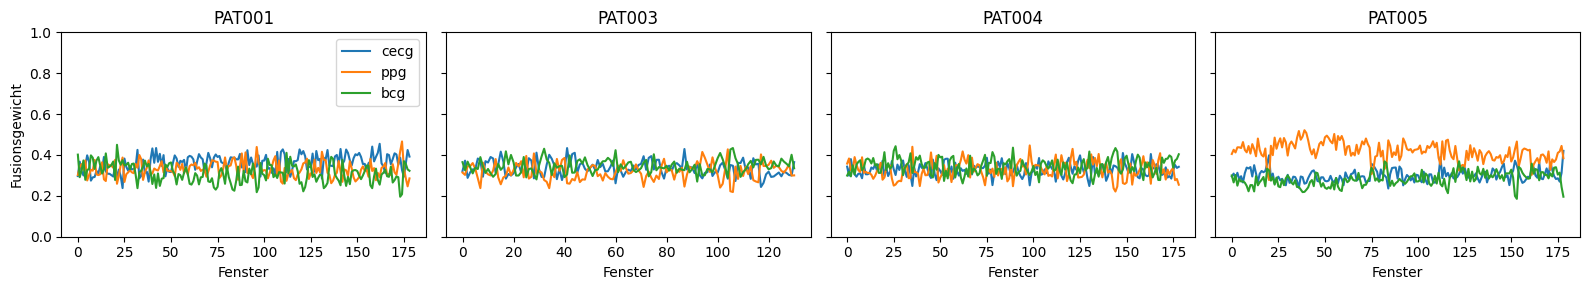

In [ ]:
# Gewichtsverläufe für vier Beispiel-Patienten (bewegt sich das Gewicht je Fenster?)
import matplotlib.pyplot as plt
ex = list(pd.unique(W['patient']))[:4]
fig, axes = plt.subplots(1, len(ex), figsize=(4*len(ex), 3), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), ex):
    sub = W[W['patient'] == pid]
    for m in G.ORDER:
        ax.plot(range(len(sub)), sub[f'w_{m}'].values, label=m)
    ax.set_title(pid); ax.set_xlabel('Fenster'); ax.set_ylim(0, 1)
np.atleast_1d(axes)[0].set_ylabel('Fusionsgewicht'); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

## 8 · Adaptivität — bringt die FENSTERWEISE SQI-Steuerung etwas? (Item 7/8)

`equal` → `*-fix` (gelerntes, eingefrorenes Mittelgewicht) → `*-win` (volles
Pro-Fenster-Gate). Δ(fix→win) ist der eigentliche Beitrag der fensterweisen Adaptivität.

In [ ]:
adt = CV.compare_adaptivity(df, rel, y, groups, base_gate=BEST_GATE,
                            target_metric=BEST_TARGET, inner_splits=5,
                            min_spec=0.80, fold_cache=fold_cache)
print(adt[['variant','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))
print('\\nΔ(equal→fix)=Nutzen fester gelernter Umgewichtung · Δ(fix→win)=Nutzen der '
      'Pro-Fenster-Steuerung. Ist Δ(fix→win)~0, ist das Gate faktisch eine feste Gewichtung.')

variant   AUC  Sensitivität  Spezifität  Accuracy  threshold
  equal 0.924         0.902       0.792     0.844      0.476
 gb-fix 0.925         0.906       0.791     0.846      0.475
 gb-win 0.924         0.908       0.790     0.846      0.466
\nΔ(equal→fix)=Nutzen fester gelernter Umgewichtung · Δ(fix→win)=Nutzen der Pro-Fenster-Steuerung. Ist Δ(fix→win)~0, ist das Gate faktisch eine feste Gewichtung.


## 8.5 · Leakage-Audit: was darf ins Gate, was in die Fusion?

Aus dem Review übernommen — und es überstimmt die frühere Idee „ACF-Peak als
Gate-Feature". Der **Phantom-Test** für jedes Gate-Feature:

> *Wäre dieses Feature bei einem Signal mit perfektem SNR, aber komplett irregulären
> Schlägen hoch oder niedrig?* — spiegelt es **Rhythmus**, ist es AF-informativ und
> gehört **nicht** ins Gate (sonst lernt das Gate das Label durch die Hintertür).

| ✅ Gate (Qualität, AF-orthogonal) | ❌ Nicht ins Gate (AF-informativ) |
|---|---|
| pSQI/bSQI/tSQI/kSQI, composite | ACF-Peak (Rhythmus-Regularität) |
| `sqi_*_xcorr` (Inter-Kanal-Morphologie) | RR-Variabilität, CoSEn |
| `sqi_xmodal_*` (HR-Konsens ≈ Detektierbarkeit) | Experten-AF-Prob |
| Nachbar-Kontext (`*_prev/_next`) | Prob-Diskordanz zwischen Modalitäten |

ACF/robuste-RR bleiben **Experten-Features** (dort sollen sie AF-informativ sein — sie
haben BCG 0.68→0.81 gebracht). Die **Diskordanz** ist nicht wertlos, sie gehört nur eine
Ebene höher: in den **Fusions-/Stacking-Layer**, wo sie kein Leck ist.

In [ ]:
# Diskordanz im FUSIONS-Layer (konzeptuell sauber): Meta-Klassifikator auf
# [p_cecg,p_ppg,p_bcg] (+ |p_m - median(andere)|). Vergleich gegen reine Probs.
import pandas as pd
rows = []
for sc in ['logreg', 'gb']:
    for sf in ['probs', 'probs+discord']:
        m, t = CV.evaluate_moe(df, rel, y, groups, fusion='stacked', stack_clf=sc,
                               stack_features=sf, inner_splits=5, min_spec=0.80,
                               fold_cache=fold_cache)
        rows.append({'stacker': f'{sc}:{sf}',
                     **{k: m[k] for k in ['AUC','Sensitivität','Spezifität','Accuracy']}, 'threshold': t})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print('\nLesart: bringt probs+discord ueber probs hinaus etwas, ist die Konsens-Info im '
      'Fusions-Layer nuetzlich — ohne das Gate konzeptuell zu verunreinigen.')

             stacker   AUC  Sensitivität  Spezifität  Accuracy  threshold
        logreg:probs 0.922         0.899       0.787     0.841      0.415
logreg:probs+discord 0.915         0.898       0.779     0.836      0.422
            gb:probs 0.902         0.936       0.729     0.828      0.340
    gb:probs+discord 0.903         0.940       0.721     0.826      0.326

Lesart: bringt probs+discord ueber probs hinaus etwas, ist die Konsens-Info im Fusions-Layer nuetzlich — ohne das Gate konzeptuell zu verunreinigen.


## 9 · Experten verbessern (Item 1 & 3)

### 9a · Neue Features (v2): ACF-Regularität + robuste RR
Die v2-Features (`*_acf_peak/_bpm/_width`, `*_RR_CV/_RMSSDn/_dRR_MAD`) stecken bereits
in der geladenen Tabelle. Abschnitt 2 hat damit gerechnet. Zum sauberen Vorher/Nachher
die Experten **ohne** v2-Spalten gegen **mit** vergleichen.

In [ ]:
# Ablation: OOF-AUC OHNE die v2-Spalten (alte Feature-Sicht) vs. MIT (aktuell).
v2_suffix = ('_acf_peak','_acf_bpm','_acf_width','_RR_CV','_RMSSDn','_dRR_MAD')
def auc_without_v2(modality):
    cols = E.expert_feature_cols(df, modality)
    keep = [c for c in cols if not c.endswith(v2_suffix)]
    # frische Experten-Pipeline nur auf den Alt-Spalten, gleiche OOF-Logik
    sub = df[['patient','AF','win_idx'] + keep].copy()
    oof_old = X.oof_expert_probs(sub, y, groups, clf_per_modality={modality: 'LR'}, n_splits=5)
    return roc_auc_score(y, oof_old[f'p_{modality}'])

print(f'{"Mod":5s} {"alt (ohne v2)":>14s} {"neu (mit v2)":>13s}  Δ')
for m in G.ORDER:
    a_old, a_new = auc_without_v2(m), auc_solo[m]
    print(f'{m:5s} {a_old:14.3f} {a_new:13.3f}  {a_new-a_old:+.3f}')
print('\\nErwartung: größter Gewinn bei cECG/BCG (ACF ist detektionsfrei und greift '
      'gerade dort, wo die Peak-Detektion versagt). PPG nahe Decke -> kaum Δ.')

Mod    alt (ohne v2)  neu (mit v2)  Δ
cecg           0.811         0.809  -0.002
ppg            0.857         0.845  -0.012
bcg            0.670         0.793  +0.123
\nErwartung: größter Gewinn bei cECG/BCG (ACF ist detektionsfrei und greift gerade dort, wo die Peak-Detektion versagt). PPG nahe Decke -> kaum Δ.


In [ ]:
# 9b · Stärkere Klassifikatoren je Experte (XGB / Kalibrierung / Mischung).
# Eigener Fold-Cache je clf-Konfiguration (Signatur enthält die clf-Wahl).
from sklearn.metrics import roc_auc_score
for name, clf in [('XGB',  {'cecg':'XGB','ppg':'XGB','bcg':'XGB'}),
                  ('MIX',  {'cecg':'XGB','ppg':'LR','bcg':'XGB'}),
                  ('MIXc', {'cecg':'XGB+cal','ppg':'LR+cal','bcg':'XGB+cal'})]:
    oof_c = X.oof_expert_probs(df, y, groups, clf_per_modality=clf, n_splits=5)
    aucs = {m: round(roc_auc_score(y, oof_c[f'p_{m}']), 3) for m in G.ORDER}
    print(f'  {name:5s} {clf}  ->  {aucs}')

  XGB   {'cecg': 'XGB', 'ppg': 'XGB', 'bcg': 'XGB'}  ->  {'cecg': 0.871, 'ppg': 0.804, 'bcg': 0.825}
  MIX   {'cecg': 'XGB', 'ppg': 'LR', 'bcg': 'XGB'}  ->  {'cecg': 0.871, 'ppg': 0.845, 'bcg': 0.825}
  MIXc  {'cecg': 'XGB+cal', 'ppg': 'LR+cal', 'bcg': 'XGB+cal'}  ->  {'cecg': 0.853, 'ppg': 0.854, 'bcg': 0.819}


In [ ]:
# 9b (Forts.) · PPG-Experte direkt tunen (PPG ist die Decke). Danach Mischkonfig +
# Fusion auf eigenem Fold-Cache. n_jobs hoch ist hier sicher (kein torch).
best_ppg, _ = X.tune_expert(df, y, groups, 'ppg', clf='LR', n_trials=80, cv_splits=5, n_jobs=8)
MIX_T = {'cecg': 'XGB+cal', 'ppg': ('LR+cal', best_ppg), 'bcg': 'XGB+cal'}
fold_cache_t = CV.precompute_folds(df, y, groups, clf_per_modality=MIX_T,
                                   inner_splits=5, random_state=42, n_jobs=-1, cache_dir=DATA_DIR)
oof_t = X.oof_expert_probs(df, y, groups, clf_per_modality=MIX_T, n_splits=5)
for m in G.ORDER:
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_t[f"p_{m}"]):.3f}')
print()
print(CV.compare_fusion(df, rel, y, groups, clf_per_modality=MIX_T,
                        weighted_gates=('equal',), stack_clfs=('logreg',),
                        inner_splits=5, fold_cache=fold_cache_t).round(3).to_string(index=False))

[I 2026-06-12 05:49:06,369] A new study created in memory with name: no-name-bb753c6a-c129-4748-a053-eb43d86d0c46
[I 2026-06-12 05:49:13,591] Trial 6 finished with value: 0.8581970197156831 and parameters: {'C': 0.011514076114866642}. Best is trial 6 with value: 0.8581970197156831.
[I 2026-06-12 05:49:13,683] Trial 0 finished with value: 0.8566943880273177 and parameters: {'C': 0.003490535598398576}. Best is trial 6 with value: 0.8581970197156831.
[I 2026-06-12 05:49:13,720] Trial 3 finished with value: 0.8577521893177861 and parameters: {'C': 0.028606820479415058}. Best is trial 6 with value: 0.8581970197156831.
[I 2026-06-12 05:49:13,721] Trial 1 finished with value: 0.8560870509125292 and parameters: {'C': 0.002834743306876434}. Best is trial 6 with value: 0.8581970197156831.
[I 2026-06-12 05:49:14,033] Trial 5 finished with value: 0.8562312280143805 and parameters: {'C': 0.13541684366448087}. Best is trial 6 with value: 0.8581970197156831.
[I 2026-06-12 05:49:14,813] Trial 4 finish

ppg LR: beste OOF-AUC = 0.858 · Params: {'C': 0.012797294789858483}
Berechne Experten-Schicht für 40 Folds (sig=038880ac79f991b1, n_jobs=-1) ...
  fertig in 142.1s · 40 Folds
  gespeichert: results/fold_expert_cache_038880ac79f991b1.joblib
  cecg : OOF-AUC = 0.853
  ppg  : OOF-AUC = 0.865
  bcg  : OOF-AUC = 0.819

        fusion   AUC  Sensitivität  Spezifität  Accuracy  threshold
weighted:equal 0.932         0.889       0.817     0.851      0.482
stacked:logreg 0.934         0.895       0.806     0.848      0.412


### 9c · 10-Sekunden-Fenster (Item 3)

**Ehrliche Abwägung:** kürzere Fenster lokalisieren Artefakte besser und liefern mehr
Trainingsfenster, ABER pro Fenster bleiben weniger Schläge (~10–13 bei 60–80 bpm). Die
RR-Irregularitätsmaße (CoSEn, DFA-α1, rrShannon) brauchen genügend Schläge — `DFA_a1`
verlangt ≥12 RR, `dfa_alpha1` nutzt Skalen bis 16. Bei 10 s fallen viele dieser Features
auf NaN. Die **detektionsfreien ACF-Features** leiden weniger. Daher 10 s **separat**
extrahieren und gegen 30 s vergleichen — nicht das 30-s-Setup ersetzen.

In [ ]:
# Separate 10-s-Extraktion (eigener Cache via window_s/hop_s in der Signatur).
cfg10 = E.ExtractConfig(data_root=DATA_ROOT, af_list='data/AF_patients.txt',
                        fs=128, window_s=10, hop_s=5, use_af_rr=True, min_valid_hrv=0)
df10 = E.load_or_extract(cfg10, DATA_DIR, n_jobs=8, force=False)
df10, y10, groups10 = E.split_Xygroups(df10)
print('10-s-Tabelle:', df10.shape)

# NaN-Rate der RR-Features prüfen (das Risiko bei kurzen Fenstern)
for m in G.ORDER:
    sig = {'cecg':'cecg','ppg':'ppg1','bcg':'bcg1'}[m]
    for f in ['CoSEn','DFA_a1','acf_peak']:
        col = f'{sig}_{f}'
        if col in df10.columns:
            print(f'  {col:18s} NaN-Rate 10s: {df10[col].isna().mean()*100:5.1f}%  '
                  f'| 30s: {df[col].isna().mean()*100:5.1f}%')

# OOF-AUC je Experte bei 10 s (direkt mit Abschnitt 2 / 30 s vergleichbar)
oof10 = X.oof_expert_probs(df10, y10, groups10, n_splits=5)
print('\\nOOF-AUC je Experte @10s (vs. 30s in Abschnitt 2):')
for m in G.ORDER:
    print(f'  {m:5s}: {roc_auc_score(y10, oof10[f"p_{m}"]):.3f}')

Cache gefunden -> lade results/features_sqi_cecg_cwt_b5d423.csv
10-s-Tabelle: (14291, 205)
  cecg_CoSEn         NaN-Rate 10s:   3.1%  | 30s:   0.5%
  cecg_DFA_a1        NaN-Rate 10s:  89.1%  | 30s:   7.5%
  cecg_acf_peak      NaN-Rate 10s:   0.0%  | 30s:   0.0%
  ppg1_CoSEn         NaN-Rate 10s:  17.3%  | 30s:  12.2%
  ppg1_DFA_a1        NaN-Rate 10s:  98.8%  | 30s:  37.9%
  ppg1_acf_peak      NaN-Rate 10s:   0.0%  | 30s:   0.0%
  bcg1_CoSEn         NaN-Rate 10s:   0.0%  | 30s:   0.0%
  bcg1_DFA_a1        NaN-Rate 10s: 100.0%  | 30s:   0.2%
  bcg1_acf_peak      NaN-Rate 10s:   0.0%  | 30s:   0.0%


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [26]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [26]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [26]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/nik/projects/BA/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [26]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/hom

\nOOF-AUC je Experte @10s (vs. 30s in Abschnitt 2):
  cecg : 0.727
  ppg  : 0.840
  bcg  : 0.729


/home/nik/projects/BA/.venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: [26]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 10 · Anhang (optional, teuer)

### 10a · torch-MLP-Gate (Optuna, Bachelet 3.7.3 → AF)
Nur ausführen, wenn das gelernte Gate in Abschnitt 6/8 überhaupt etwas über `equal`
bringt — sonst ist das Tuning verlorene Zeit (das Gate ist informations-, nicht
modellbegrenzt). Ziel `drr_sd_err` (vom SQI am besten vorhergesagt).

In [ ]:
import pickle
TORCH_PKL = 'results/best_torch.pkl'
if os.path.exists(TORCH_PKL):
    best_torch = pickle.load(open(TORCH_PKL, 'rb')); print('best_torch geladen:', best_torch)
else:
    best_torch, study = CV.tune_torch_gate(df, rel, y, groups, target_metric='drr_sd_err',
                                            n_trials=100, cv_splits=5, random_state=42, n_jobs=1)
    os.makedirs('results', exist_ok=True); pickle.dump(best_torch, open(TORCH_PKL, 'wb'))
    print('best_torch gespeichert.')

tab_torch = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb','torch_mlp'),
                             target_metric='drr_sd_err', gate_params=best_torch,
                             inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print(tab_torch[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))

best_torch geladen: {'hidden_dims': (128,), 'lr': 0.00010033955064809462, 'weight_decay': 0.0013981496979578987, 'batch_size': 64, 'max_epochs': 20, 'patience': 45, 'dropout': 0.28336659861569313}


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


     gate   AUC  Sensitivität  Spezifität  Accuracy  threshold
    equal 0.924         0.902       0.792     0.844      0.476
       gb 0.929         0.922       0.781     0.849      0.447
torch_mlp 0.927         0.913       0.780     0.843      0.457


## Roadmap / Handoff (Stand dieser Sitzung)

**Erledigt im Code (`src/`, Feature-Version `v2_acf_xmodal`):**
- `features.py`: detektionsfreies `autocorr_regularity` (acf_peak/bpm/width) — greift
  gerade bei cECG/BCG, wo die Peak-Detektion die Schwachstelle ist; robuste RR-Maße
  (RR_CV, RMSSDn, dRR_MAD). Bug `cv_max=NONE` in `af_rr_bcg` behoben.
- `extract.py`: `cross_modal_hr_agreement` als GT-freier Gate-Eingang verdrahtet
  (`sqi_xmodal_n_agree/_confidence/_trustworthy`); `FEAT_VERSION` in den Cache-Hash
  aufgenommen (alte Caches werden sauber invalidiert).

**Nächste Schritte (priorisiert):**
1. **Notebook 01 mit aktuellem `src/` neu extrahieren** (erzeugt die v2-Tabelle).
2. Abschnitt 2-3 entscheiden, ob cECG/BCG nach v2 überhaupt etwas BEITRAGEN
   (PPG-Ablation). Falls nein: Fusion ist PPG-limitiert — ehrlich in die Diskussion.
3. Abschnitt 3-4: schwere Fenster mit *vorhandener* RR gezielt ansehen → Detektor
   (`detect_peaks_bcg_cwt` vs. `_v2`) oder Feature dort verbessern.
4. Abschnitt 5: bringen die `sqi_xmodal_*`-Eingänge `r(pred,true)` nach oben? Nur dann
   kann fensterweises Gating greifen.
5. 10-s-Fenster nur weiterverfolgen, wenn die RR-NaN-Rate vertretbar bleibt.

**Mit Blaß bestätigen:** Gate-Ziel CoSEn/dRR_SD (nicht HR); Kanal-Aggregation
PPG/BCG = bester Kanal; ist die PPG-limitierte Decke ein akzeptables Ergebnis.

---

### Aus dem externen Review übernommen (diese Sitzung)
**Code (`src/`, Feature-Version `v3_acf_xmodal_xcorr`):**
- `gating.py`: `target_transform` ('standard'|'quantile'|'log') im Gate; `blend_weights`/
  `errors_to_weights_blended` (R²-Blend Richtung Gleichgewicht); Clip negativer err in
  `errors_to_weights_exp`.
- `fusion_cv.py`: `evaluate_moe(..., target_transform=, blend_trust=, stack_features=)`;
  leckagefreies `_gate_trust_inner` (inner GroupKFold); `_add_discordance` für den
  Fusions-Layer; `gate_predictive_validity(..., target_transform=)`.
- `extract.py`: `sqi_*_xcorr` (Inter-Kanal-Qualität, AF-orthogonal); `add_neighbor_context`
  (zeitlicher Gate-Kontext); FEAT_VERSION → v3.

**Bewusst NICHT übernommen (mit Begründung):**
- *„Temperatur kollabiert nach TransformedTargetRegressor auf ~0"* — falsch: `predict()`
  liefert Original-Fehlereinheiten zurück (geprüft), `scale=median(err)` ist gesund.
- *„ACF-Peak als Gate-Feature"* — widerspricht dem eigenen Leakage-Argument; ACF bleibt
  Experten-Feature (Phantom-Test).

**Reihenfolge zum Ausprobieren:** (1) Abschnitt 5a/5b — bringt quantile/gb das r hoch?
(2) Abschnitt 6 Varianten — schlägt gb+quant+blend die naive Fusion? (3) Abschnitt 8.5 —
hilft Diskordanz im Stacking? Wenn alles ~ equal bleibt: das ist das ehrliche Ergebnis
(PPG-limitierte Decke) und gehört genau so in die Diskussion.
